In [74]:
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd, xarray as xr, scipy.io as sio

%matplotlib inline
import matplotlib.pyplot as plt
import cartopy.crs as ccrs, cartopy.feature as cfeature
from scipy.interpolate import griddata
from scipy.spatial import cKDTree
plt.rcParams['figure.dpi'] = 110

DATA = Path('/Users/advik/Library/Mobile Documents/com~apple~CloudDocs/Documents/'
            'Documents - MacBook Air/Python/Ice Cores/data/model/ccsm4_last_millenium')
AWS_MAT = Path.home()/'Downloads'/'Mathieu'/'Data'/'dataAWS.mat'

N_POTENTIAL, N_EXIST = 5794, 118      # rows 0..5793 potential; 5794..5911 existing cores
N_SITES = N_POTENTIAL + N_EXIST

ENSEMBLE = 'MME'      # 'MME' (1001 members) | 'MRE' (160)
VARIABLE = 'Temp'     # 'Temp' | 'Accum'
R_MODE   = 'accumR'   # 'accumR' (RSheet) | 'orogR'

# Error variance given to the AWS sites when they are assimilated, as a
# multiple of the proxy R. 1.0 = "a proxy record at the station location"
# (the question as posed). Values << 1 treat them as instrumental
# observations. THIS SINGLE CHOICE DOMINATES THE RESULT -- see Cell 7.
AWS_R_SCALE = 1.0

print('DATA ok:', DATA.exists(), '| AWS ok:', AWS_MAT.exists())

# RSheet is an ACCUMULATION error variance (implied SE ~11, i.e. 11 mm/yr).
# The temperature estimates are in K, where an 11 K standard error is not a
# real measurement uncertainty -- so for VARIABLE='Temp' set R directly, in K^2.
USE_ABSOLUTE_TEMP_R = True
R_PROXY_TEMP = 2.0     # K^2, ice-core annual temperature reconstruction error
R_AWS_TEMP   = 0.5     # K^2, station representativeness (point vs grid cell)

# Error variances (K^2, since the temperature estimates are in K).
R_AWS_ASSIM = 0.0    # existing AWS treated as perfect observations
R_PROXY     = 2.0    # a new ice core: annual d18O->T reconstruction error
# A new AWS uses R = 0 (same footing as the existing network).




DATA ok: True | AWS ok: True


In [75]:
def read_numbers(path):
    out = []
    for tok in Path(path).read_text().split():
        try: out.append(float(tok))
        except ValueError: pass
    return np.asarray(out, float)

N_BLOCKS, DEBLOCK_MRE = 4, True

def deblock(X, n_blocks=N_BLOCKS):
    """Remove each reanalysis's own mean along the member axis.

    The MRE ensemble concatenates 4 reanalysis products. Its temperature metric
    has one block (ERA5) sitting ~40 K below the others, so >99% of the raw
    'variance' is that offset. Deblocked, MRE temperature variance drops from
    321.6 to 0.441 K^2 -- in line with MME's 0.620. Must be applied to the
    metric and estimates consistently. Never applied to MME.
    """
    X = np.asarray(X, float)
    if X.shape[-1] % n_blocks:
        raise ValueError(f'{X.shape[-1]} members not divisible by {n_blocks}')
    return np.concatenate([b - b.mean(-1, keepdims=True)
                           for b in np.split(X, n_blocks, axis=-1)], axis=-1)

def load_Ye(variable=None, ensemble=None):
    variable, ensemble = variable or VARIABLE, ensemble or ENSEMBLE
    key = f'{variable}{ensemble}Ye'
    Ye = np.asarray(sio.loadmat(DATA / f'{key}.mat')[key], float)
    assert Ye.shape[0] == N_SITES, Ye.shape
    return deblock(Ye) if (ensemble == 'MRE' and DEBLOCK_MRE) else Ye

def load_metric(variable=None, ensemble=None):
    variable, ensemble = variable or VARIABLE, ensemble or ENSEMBLE
    key = f'{ensemble}{variable}'
    J = np.asarray(sio.loadmat(DATA / f'{key}.mat')[key], float).ravel()
    return deblock(J) if (ensemble == 'MRE' and DEBLOCK_MRE) else J

def load_R(mode=None, clip_negative=True):
    """Observation error variances, one per site (5912).

    Called with NO arguments it honours USE_ABSOLUTE_TEMP_R and returns a
    constant R_PROXY_TEMP (K^2) for temperature. Called with an explicit
    `mode` it always reads the file, so validation against MATLAB is
    unaffected by the config.
    """
    if mode is None and VARIABLE == 'Temp' and USE_ABSOLUTE_TEMP_R:
        return np.full(N_SITES, float(R_PROXY_TEMP))
    mode = mode or R_MODE
    if mode == 'accumR':
        R = read_numbers(DATA / 'RSheet.csv')
    elif mode == 'orogR':
        R = np.concatenate([read_numbers(DATA / 'orographyR.csv')[:N_POTENTIAL],
                            read_numbers(DATA / 'orographyRExist.csv')[:N_EXIST]])
    else:
        raise ValueError(mode)
    if np.isnan(R).any(): R = np.nan_to_num(R, nan=0.0)
    if clip_negative and (R < 0).any(): R = np.clip(R, 0, None)
    assert R.size == N_SITES, R.size
    return R



Ye, J, R = load_Ye(), load_metric(), load_R()
assert J.size == Ye.shape[1], (J.size, Ye.shape[1])

nM = Ye.shape[1]; unbias = 1/(nM - 1)
Yvar = unbias * ((Ye - Ye.mean(1, keepdims=True))**2).sum(1)
J0var = unbias * ((J - J.mean())**2).sum()
print(f'{ENSEMBLE} {VARIABLE}:  Ye {Ye.shape}   J {J.shape}   R {R.shape}')
print(f'  metric variance {J0var:.6g} | median Ye var {np.median(Yvar):.4g} '
      f'| median R {np.median(R):.4g}')
ratio = np.median(R[:N_POTENTIAL]) / np.median(Yvar[:N_POTENTIAL])
print(f'  median R / Ye var {ratio:.2f}')
if ratio > 5:
    print('  WARNING: R-dominated. RSheet is scaled for accumulation; on '
          'temperature the units do not match, so deltaVar ~ cov^2 / R.')


MME Temp:  Ye (5912, 1001)   J (1001,)   R (5912,)
  metric variance 0.619854 | median Ye var 1.065 | median R 2
  median R / Ye var 1.88


In [76]:
# ---------------------------------------------------------------------------
# R = k / A, with k ESTIMATED from replicate ice cores.
#
# 42 core pairs within 60 km and >=25 overlapping years give a median
# var(core_i - core_j)/2 = 2.202 per mil^2 -- the local (non-climate) noise.
# Against a total d18O variance of 2.46 per mil^2, ~90% of annual d18O
# variance is noise, and inter-core r is 0.03-0.37 even at 0 km separation.
#
#   k = (dT/dd18O)^2 * sigma2_noise * A_at_those_sites
#
# CAVEAT: every pair is in Dronning Maud Land (lat ~ -75, lon 353-7E), so this
# anchors the CONSTANT at A ~ 88 mm/yr but does not test the 1/A exponent --
# that is inherited from RSheet's construction.
# ---------------------------------------------------------------------------
D18O_TO_T   = 2.0        # K per mil; the Ant-2K script uses 1.5 and 2.0
SIGMA2_D18O = 2.202      # per mil^2, median over the 42 replicate pairs
A_CALIB     = 88.2       # mm/yr, model accumulation at the DML pair sites

accum_rate = sio.loadmat(DATA / 'AccumMMEYe.mat')['AccumMMEYe'].mean(1)[:N_POTENTIAL]

_Rsheet = read_numbers(DATA / 'RSheet.csv')[:N_POTENTIAL]
assert np.allclose(_Rsheet * accum_rate, 1e4, rtol=1e-6), 'RSheet is not 10000/A'
print(f'RSheet = 10000 / A  -- exact for all {N_POTENTIAL} potential sites')

K_TEMP = D18O_TO_T**2 * SIGMA2_D18O * A_CALIB
R_ICE_CORE = K_TEMP / accum_rate

print(f'k_temp = {K_TEMP:.0f}   (dT/dd18O = {D18O_TO_T}, sigma2 = {SIGMA2_D18O})')
print(f'  R range {R_ICE_CORE.min():.2f} .. {R_ICE_CORE.max():.2f} K^2 '
      f'(SE {np.sqrt(R_ICE_CORE.min()):.2f} .. {np.sqrt(R_ICE_CORE.max()):.2f} K)')
print(f'  median {np.median(R_ICE_CORE):.2f} K^2, vs Ye variance median '
      f'{np.median(Yvar[:N_POTENTIAL]):.2f} K^2')

if VARIABLE == 'Accum':
    R_ICE_CORE = _Rsheet
    print('  (VARIABLE=Accum -> using RSheet directly)')


RSheet = 10000 / A  -- exact for all 5794 potential sites
k_temp = 777   (dT/dd18O = 2.0, sigma2 = 2.202)
  R range 0.74 .. 37.75 K^2 (SE 0.86 .. 6.14 K)
  median 9.70 K^2, vs Ye variance median 1.06 K^2


In [77]:
# CCSM4 (CAM4 finite-volume) grid, generated analytically -- identical to
# reading lat/lon from the 2.6 GB pr_sfc_Amon_CCSM4 file, but instant.
ccsm_lat = np.linspace(-90, 90, 192)
ccsm_lon = np.arange(288) * 1.25

def build_site_coords():
    """FindGridSites.ipynb: first 32 latitude rows, masked to land by a
    regridded ERA5 t2m field (data.nc, 2 MB)."""
    era = xr.open_dataset(DATA / 'data.nc')
    t2m = era[list(era.data_vars)[0]].values
    tempMask = np.roll(t2m, 1800, axis=2)
    latInd = pd.read_csv(DATA / 'latInd.csv').values.ravel().astype(int)
    tr = np.zeros((32, 3600))
    for i, it in enumerate(latInd):
        tr[i, :] = tempMask[0, it]
    sec = np.zeros((32, 7200))
    for i in range(32):
        sec[i, :7198] = np.dstack((tr[i, :-1],
                                   tr[i, :-1] + np.diff(tr[i])/2.0)).ravel()
    rg = sec[:, ::25]
    la, lo = [], []
    for i in range(32):
        for j in range(288):
            if rg[i, j] > 0:
                la.append(ccsm_lat[i]); lo.append(ccsm_lon[j])
    return np.array(la), np.array(lo)

site_lat, site_lon = build_site_coords()
assert site_lat.size == N_POTENTIAL, site_lat.size
print(f'{site_lat.size} potential sites, lat {site_lat.min():.1f} to {site_lat.max():.1f}')


5794 potential sites, lat -90.0 to -62.7


In [78]:
TINY = 1e-12

def variance_reduction(Jdev, Ydev, Rvar, unbias):
    """DASH varianceReduction.m, guarded for R = 0.

    With R = 0 a site whose deviations have collapsed (fully explained by an
    earlier assimilation) gives 0/0. Those sites carry no information left, so
    the variance they constrain is 0.
    """
    den = unbias * (Ydev ** 2).sum(1) + Rvar
    num = (unbias * (Ydev @ Jdev)) ** 2
    return np.where(den > TINY, num / np.where(den > TINY, den, 1.0), 0.0)

def adjusted_gain(Knum, Kdenom, Rbest):
    ks = np.sqrt(Kdenom)
    return Knum / ks / (ks + np.sqrt(Rbest))

class OptimalSensor:
    """Port of DASH @optimalSensor (Comboul et al. 2015)."""
    def __init__(self, J, Ye, R, dash_estimate_update=True):
        J = np.asarray(J, float).ravel()
        self.nM = J.size
        self.unbias = 1.0 / (self.nM - 1)
        self.Jmean, self.Jdev = J.mean(), J - J.mean()
        Ye = np.asarray(Ye, float)
        self.Ydev = Ye - Ye.mean(1, keepdims=True)
        self.R = np.asarray(R, float).ravel().copy()
        self.dash_estimate_update = dash_estimate_update
        self.J0var = self.metric_variance()

    def metric_variance(self):
        return self.unbias * (self.Jdev ** 2).sum()

    def evaluate(self):
        return variance_reduction(self.Jdev, self.Ydev, self.R, self.unbias)

    def assimilate(self, idx):
        Yb = self.Ydev[idx].copy(); Rb = self.R[idx]
        Yv = self.unbias * (Yb ** 2).sum()
        if Yv + Rb <= TINY:                 # nothing left to extract
            self.Ydev[idx] = np.nan
            return self.metric_variance()
        Ka = adjusted_gain(self.unbias * (self.Jdev @ Yb), Yv + Rb, Rb)
        self.Jdev = self.Jdev - Ka * Yb
        if self.dash_estimate_update:
            self.Ydev = self.Ydev - Ka * Yb
        else:
            KaY = adjusted_gain(self.unbias * (self.Ydev @ Yb), Yv + Rb, Rb)
            self.Ydev = self.Ydev - KaY[:, None] * Yb
        self.Ydev[idx] = np.nan
        return self.metric_variance()

    def run(self, N, exclude=None, verbose=True):
        sites, vs = [], []
        for s in range(N):
            dv = self.evaluate()
            dv = np.where(np.isfinite(dv), dv, -np.inf)
            if exclude is not None:
                dv = np.where(exclude, -np.inf, dv)
            for k in sites:
                dv[k] = -np.inf
            b = int(np.argmax(dv)); v = self.assimilate(b)
            sites.append(b); vs.append(v)
            if verbose:
                print(f'  {s+1:3d}  site {b:5d} ({site_lat[b]:7.2f}, {site_lon[b]:7.2f})  '
                      f'var {v:.6g}   cumulative {100*(1-v/self.J0var):5.1f}%')
        return np.array(sites), np.array(vs)

print('OptimalSensor defined')


OptimalSensor defined


In [79]:
# Pins the ALGORITHM to your MATLAB. Deliberately bypasses load_R and reads
# RSheet directly -- this must validate regardless of USE_ABSOLUTE_TEMP_R or
# the deblock setting, both of which legitimately change the experiment.
_ky, _kj = f'{VARIABLE}{ENSEMBLE}Ye', f'{ENSEMBLE}{VARIABLE}'
Ye_raw = np.asarray(sio.loadmat(DATA / f'{_ky}.mat')[_ky], float)
J_raw  = np.asarray(sio.loadmat(DATA / f'{_kj}.mat')[_kj], float).ravel()
R_ref  = read_numbers(DATA / 'RSheet.csv')[:N_POTENTIAL]
tgt    = read_numbers(DATA / f'BS_{ENSEMBLE}_{VARIABLE.lower()}_accumR.csv')

dv_chk = OptimalSensor(J_raw, Ye_raw[:N_POTENTIAL], R_ref).evaluate()
corr = np.corrcoef(dv_chk, tgt)[0, 1]
rel  = np.max(np.abs(dv_chk - tgt) / np.maximum(np.abs(tgt), 1e-30))
print(f'algorithm check:  1 - corr {1-corr:.3e}   max rel err {rel:.3e}  '
      f'(CSV precision floor ~5e-5)')
assert corr > 1 - 1e-8 and rel < 1e-3, 'does not match MATLAB'
print('matches the MATLAB output to the precision of the reference file')


algorithm check:  1 - corr 2.008e-10   max rel err 4.884e-05  (CSV precision floor ~5e-5)
matches the MATLAB output to the precision of the reference file


In [80]:
def haversine_km(lat1, lon1, lat2, lon2, Rk=6371.0088):
    lat1, lon1, lat2, lon2 = map(np.radians, (lat1, lon1, lat2, lon2))
    a = (np.sin((lat2-lat1)/2)**2
         + np.cos(lat1)*np.cos(lat2)*np.sin((lon2-lon1)/2)**2)
    return 2*Rk*np.arcsin(np.sqrt(np.clip(a, 0, 1)))

_aws = sio.loadmat(AWS_MAT, squeeze_me=True, struct_as_record=False)['dataAWS']
rows = []
for name in _aws._fieldnames:
    rec = getattr(_aws, name)
    la, lo = float(rec.lat), np.mod(float(rec.lon), 360.0)
    d = haversine_km(la, lo, site_lat, site_lon); k = int(np.argmin(d))
    rows.append(dict(station=name, lat=la, lon=lo, site=k,
                     site_lat=site_lat[k], site_lon=site_lon[k], dist_km=d[k]))

aws_map = pd.DataFrame(rows)
AWS_SITES = sorted(set(aws_map.site))     # dedupe: McMurdo & Scott Base share a cell
print(f'{len(aws_map)} stations -> {len(AWS_SITES)} unique grid sites; '
      f'max offset {aws_map.dist_km.max():.0f} km')
aws_map.round(2)


17 stations -> 16 unique grid sites; max offset 125 km


,station,lat,lon,site,site_lat,site_lon,dist_km
0,FaradayVernadsky,-65.14,295.85,5785,-65.50,296.25,43.86
1,Rothera,-67.34,291.92,5743,-67.38,292.50,25.26
2,Byrd,-80.01,240.68,3361,-79.63,241.25,43.34
3,Marambio,-64.24,303.37,5792,-63.61,301.25,124.90
4,Mawson,-67.60,62.90,5615,-68.32,62.50,82.28
5,Davis,-68.60,78.00,5622,-68.32,78.75,43.30
6,McMurdo,-77.90,166.70,3876,-77.75,167.50,25.20
7,DDU,-66.70,140.00,5737,-67.38,140.00,75.86
8,Bellingshausen,-62.12,301.42,5793,-62.67,300.00,95.37
9,Neumayer,-70.40,351.84,5350,-71.15,351.25,86.34


In [81]:
R_AWS_ASSIM = 0.0            # existing AWS treated as perfect observations

def experiment(candidate_R, pre_idx=None, r_assim=R_AWS_ASSIM):
    """Pre-assimilate the existing AWS network at R=r_assim, then evaluate every
    potential site as a candidate with error variance `candidate_R`."""
    pre_idx = AWS_SITES if pre_idx is None else pre_idx
    Rc = (np.full(N_POTENTIAL, float(candidate_R)) if np.isscalar(candidate_R)
          else np.asarray(candidate_R, float)[:N_POTENTIAL].copy())
    os_ = OptimalSensor(J, Ye[:N_POTENTIAL], Rc)
    J0 = os_.J0var
    Rsave = os_.R.copy()
    os_.R[list(pre_idx)] = r_assim
    for i in pre_idx:
        os_.assimilate(int(i))
    os_.R = Rsave
    dv = os_.evaluate()
    return os_, J0, os_.metric_variance(), np.where(np.isfinite(dv), dv, np.nan)

os_core, J0, v_net, dv_core = experiment(R_ICE_CORE)   # new ice core: R = k/A
os_aws,  _,  _,     dv_aws  = experiment(0.0)          # new AWS: R = 0

print(f'metric variance {J0:.5g}')
print(f'existing AWS network (R={R_AWS_ASSIM}) constrains '
      f'{100*(1-v_net/J0):.1f}%;  remaining {v_net:.5g}\n')
for lbl, dv in [('new ICE CORE (R=k/A)', dv_core), ('new AWS (R=0)', dv_aws)]:
    k = int(np.nanargmax(dv))
    print(f'  {lbl:22s} best site {k:5d} ({site_lat[k]:7.2f}, {site_lon[k]:7.2f})  '
          f'A={accum_rate[k]:6.1f}  R={dv_core.size and (R_ICE_CORE[k] if "ICE" in lbl else 0):5.2f}  '
          f'adds {100*np.nanmax(dv)/J0:6.2f}% of total, '
          f'{100*np.nanmax(dv)/v_net:6.2f}% of remaining')
ok = np.isfinite(dv_core) & np.isfinite(dv_aws)
print(f'\n  corr(ice-core map, AWS map) = {np.corrcoef(dv_core[ok], dv_aws[ok])[0,1]:.4f}')


metric variance 0.61985
existing AWS network (R=0.0) constrains 81.1%;  remaining 0.11735

  new ICE CORE (R=k/A)   best site  4656 ( -74.92,  345.00)  A= 339.3  R= 2.29  adds   1.30% of total,   6.89% of remaining
  new AWS (R=0)          best site  1757 ( -84.35,   36.25)  A=  41.8  R= 0.00  adds  11.01% of total,  58.14% of remaining

  corr(ice-core map, AWS map) = 0.5224


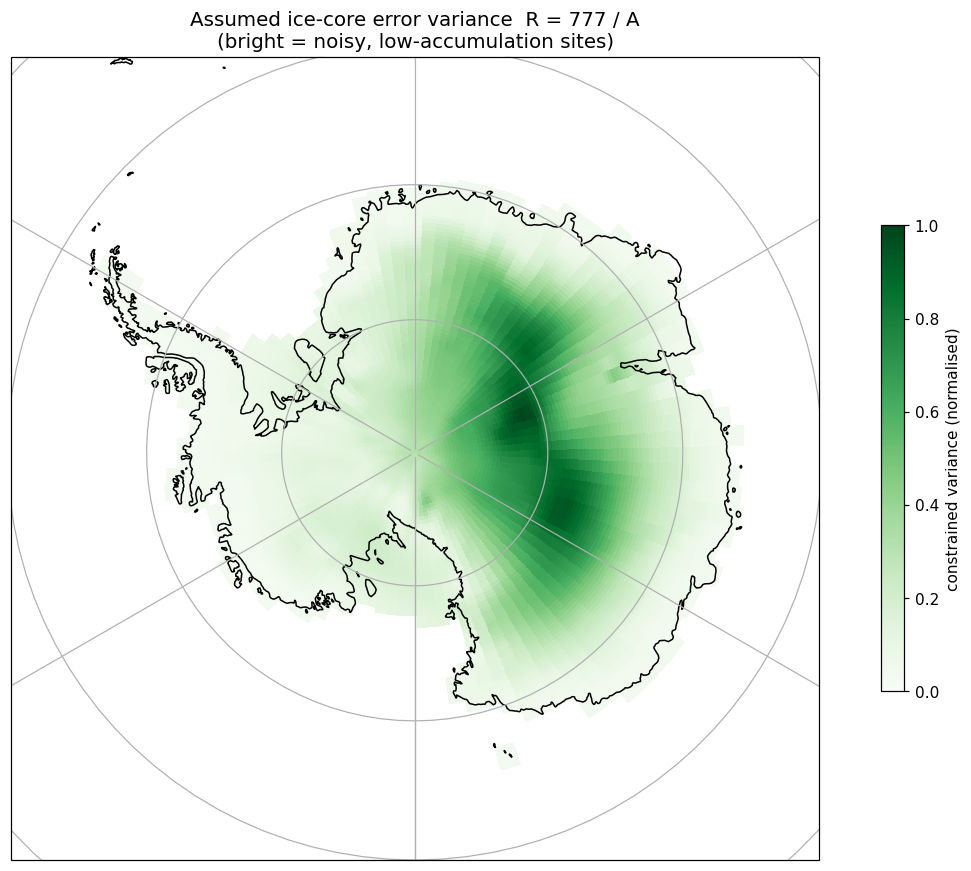

R spans 0.74-37.75 K^2, a factor of 51


In [82]:
plot_map(R_ICE_CORE / np.nanmax(R_ICE_CORE),
         f'Assumed ice-core error variance  R = {K_TEMP:.0f} / A\n'
         f'(bright = noisy, low-accumulation sites)', show_aws=False)
print(f'R spans {R_ICE_CORE.min():.2f}-{R_ICE_CORE.max():.2f} K^2, '
      f'a factor of {R_ICE_CORE.max()/R_ICE_CORE.min():.0f}')


In [83]:
def interp_field(values, ngrid=100, distance_threshold=1.0):
    v = np.asarray(values, float)
    lg = np.linspace(site_lon.min(), site_lon.max(), ngrid)
    ag = np.linspace(site_lat.min(), site_lat.max(), ngrid)
    lm, am = np.meshgrid(lg, ag)
    d, _ = cKDTree(np.column_stack((site_lon, site_lat))).query(
        np.column_stack((lm.ravel(), am.ravel())))
    g = griddata((site_lon, site_lat), v, (lm, am), method='linear')
    g[d.reshape(lm.shape) > distance_threshold] = np.nan
    return lm, am, g

def plot_map(frac, title, top_idx=None, top_size=220, show_aws=True, figsize=(12, 11)):
    lm, am, g = interp_field(frac)
    fig = plt.figure(figsize=figsize)
    ax = plt.axes(projection=ccrs.SouthPolarStereo())
    ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
    ax.gridlines()
    pm = ax.pcolormesh(lm, am, g, zorder=0, transform=ccrs.PlateCarree(),
                       cmap=plt.cm.Greens, vmin=0, vmax=1)
    if show_aws:
        ax.scatter(aws_map.lon, aws_map.lat, marker='^', s=90, c='red',
                   edgecolors='k', linewidths=.8, zorder=2,
                   transform=ccrs.PlateCarree(), label='AWS stations')
    ax.coastlines()
    if top_idx is not None:
        n = len(top_idx); ranks = np.arange(1, n+1); order = np.arange(n)[::-1]
        sc = ax.scatter(site_lon[top_idx][order], site_lat[top_idx][order],
                        c=ranks[order], s=top_size, linewidth=1.5,
                        edgecolors='black', cmap=plt.cm.cool_r,
                        vmin=.5, vmax=n+.5, zorder=3, transform=ccrs.PlateCarree())
        cbr = fig.colorbar(sc, ax=ax, shrink=.5, pad=.03, ticks=ranks)
        cbr.set_label('site rank'); cbr.ax.invert_yaxis()
    if show_aws:
        ax.legend(loc='lower left', fontsize=9, framealpha=.85)
    cb = fig.colorbar(pm, ax=ax, shrink=.5, pad=.06)
    cb.set_label('constrained variance (normalised)')
    ax.set_title(title, fontsize=13)
    plt.show()


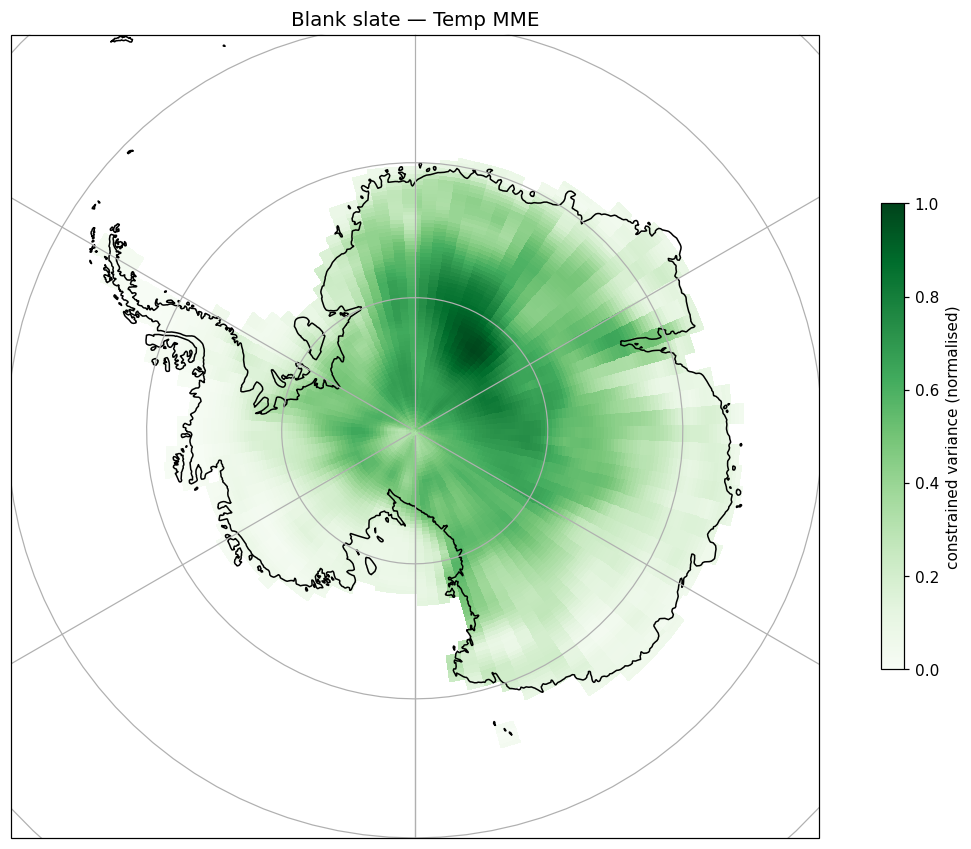

best site 2334 (-82.46, 37.50) = 32.04% of total metric variance


In [84]:
frac_blank = dv_blank / np.nanmax(dv_blank)
plot_map(frac_blank, f'Blank slate — {VARIABLE} {ENSEMBLE}', show_aws=False)
k = int(np.nanargmax(dv_blank))
print(f'best site {k} ({site_lat[k]:.2f}, {site_lon[k]:.2f}) = '
      f'{100*dv_blank[k]/J0:.2f}% of total metric variance')


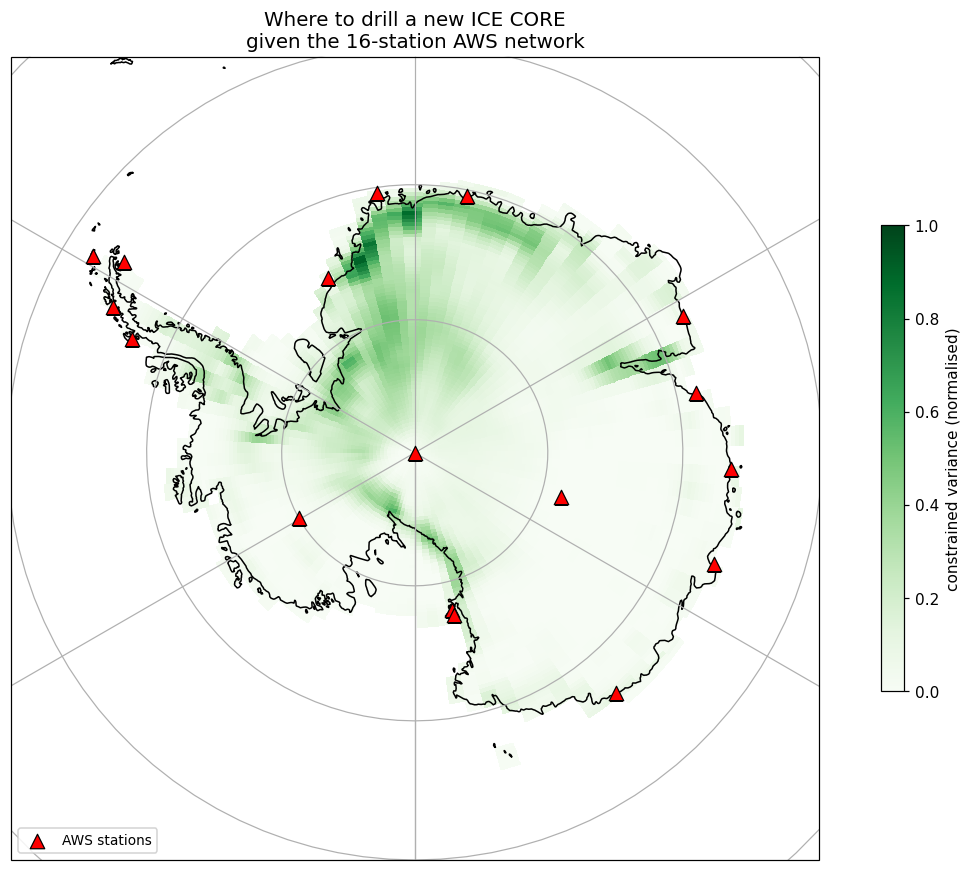

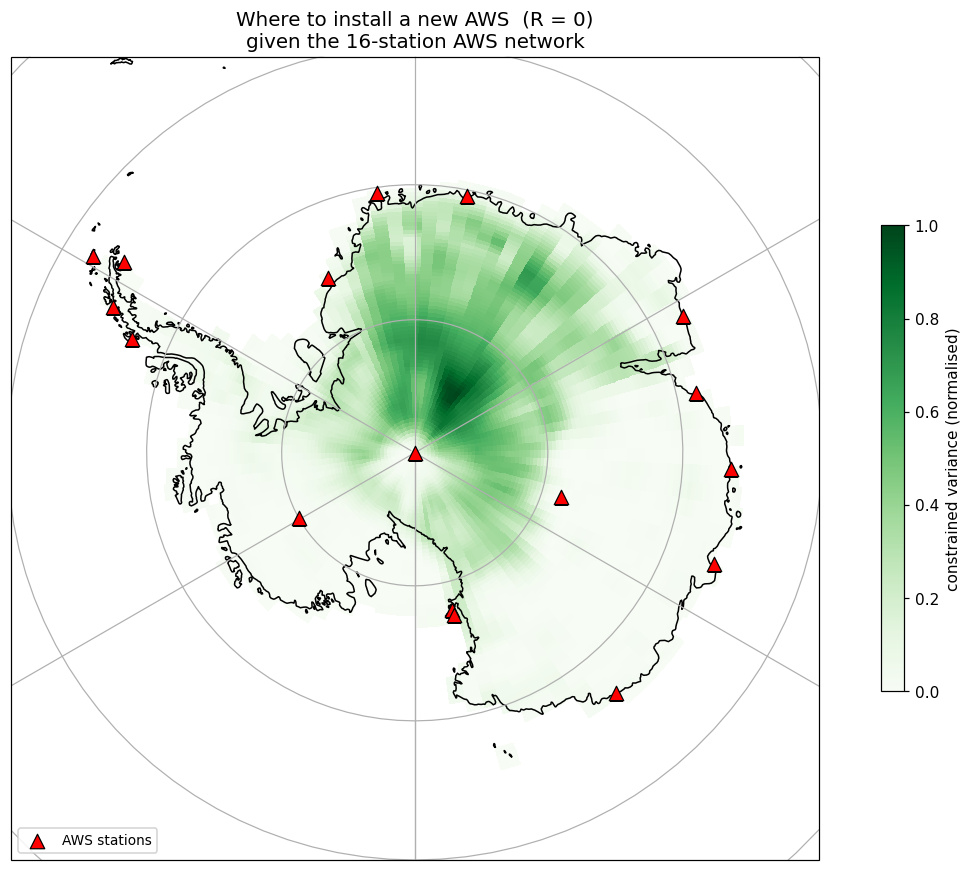

In [87]:
frac_core = dv_core / np.nanmax(dv_core)
frac_aws  = dv_aws  / np.nanmax(dv_aws)

plot_map(frac_core, f'Where to drill a new ICE CORE\n'
                    f'given the {len(AWS_SITES)}-station AWS network')
plot_map(frac_aws,  f'Where to install a new AWS  (R = 0)\n'
                    f'given the {len(AWS_SITES)}-station AWS network')



Top 10 — new ICE CORE   (AWS network leaves 0.11735 of 0.61985)
      site     lat     lon    accum       R  pct_of_total  pct_of_remaining
rank                                                                       
1     4656 -74.921  345.00  339.320   2.289        82.372             6.890
2     4657 -74.921  346.25  296.673   2.619        83.190            11.212
3     5202 -72.094  358.75  463.259   1.677        83.804            14.455
4     4721 -73.979   66.25   66.466  11.688        84.280            16.968
5     1601 -85.288  201.25  200.659   3.872        84.658            18.967
6     3448 -79.634  350.00  101.262   7.672        84.999            20.764
7     5782 -65.497   96.25  575.479   1.350        85.315            22.436
8     4646 -74.921  296.25  329.897   2.355        85.637            24.135
9     2295 -83.403  348.75   84.114   9.236        85.925            25.659
10    3160 -80.576  350.00   91.381   8.501        86.191            27.061


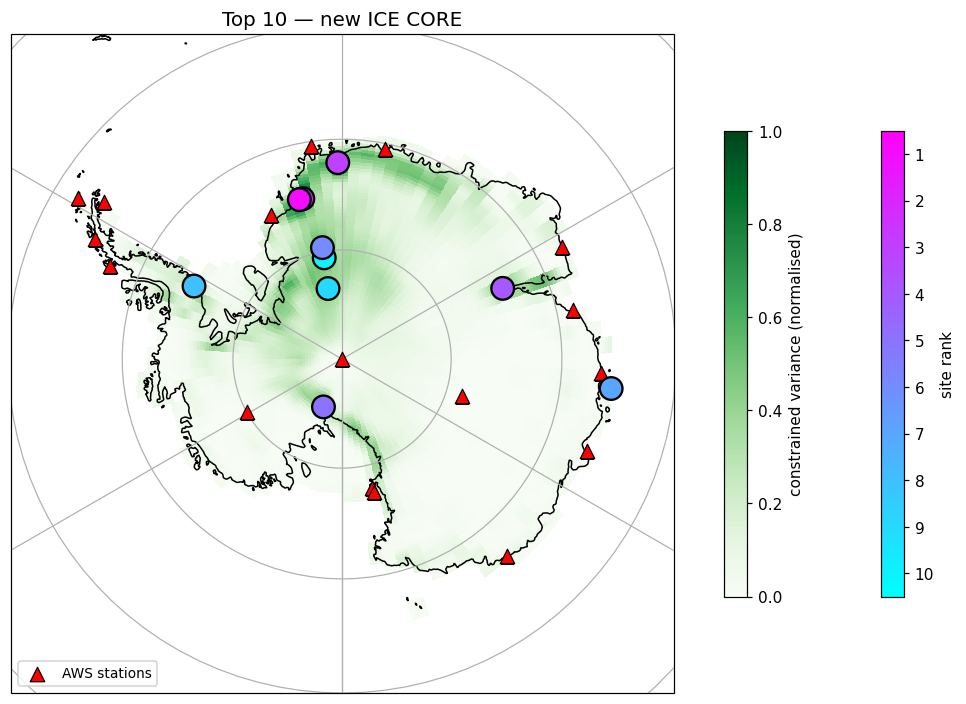


Top 10 — new AWS   (AWS network leaves 0.11735 of 0.61985)
      site     lat     lon    accum    R  pct_of_total  pct_of_remaining
rank                                                                    
1     1757 -84.346   36.25   41.787  0.0        92.075            58.142
2     1275 -86.230  153.75   55.433  0.0        96.027            79.016
3     3499 -78.691   53.75   24.556  0.0        96.911            83.682
4     2883 -80.576    3.75   59.673  0.0        97.367            86.091
5     2471 -82.461  208.75   96.277  0.0        97.770            88.223
6     1797 -84.346   86.25   29.859  0.0        98.153            90.245
7     2441 -82.461  171.25  156.678  0.0        98.393            91.510
8     4259 -75.864   30.00   37.311  0.0        98.595            92.581
9     3543 -78.691  108.75   22.074  0.0        98.745            93.372
10    2352 -82.461   60.00   24.674  0.0        98.874            94.051


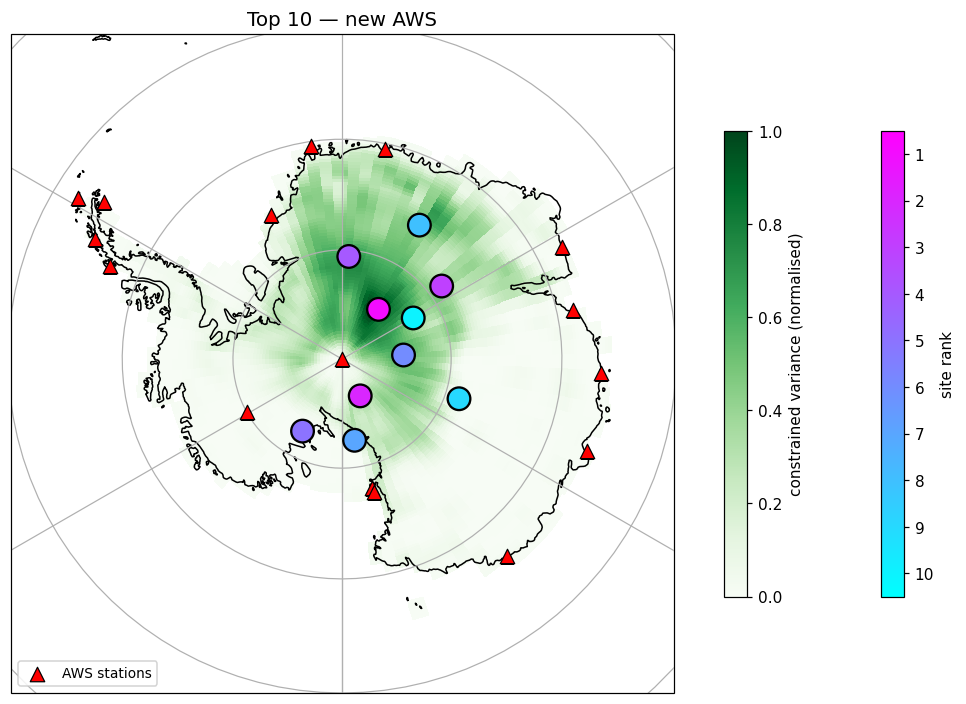

In [86]:
N_NEW = 10
results = {}

for lbl, candR, frac in [('ICE CORE', R_ICE_CORE, frac_core),
                         ('AWS',      0.0,        frac_aws)]:
    o, J0_, v0, _ = experiment(candR)
    print(f'\nTop {N_NEW} — new {lbl}   '
          f'(AWS network leaves {v0:.5g} of {J0_:.5g})')
    st, vr = o.run(N_NEW, verbose=False)
    assert (st < N_POTENTIAL).all()

    tbl = pd.DataFrame({
        'rank': np.arange(1, N_NEW + 1),
        'site': st,
        'lat': site_lat[st],
        'lon': site_lon[st],
        'accum': accum_rate[st],
        'R': (R_ICE_CORE[st] if lbl == 'ICE CORE' else np.zeros(N_NEW)),
        'pct_of_total': 100 * (1 - vr / J0_),
        'pct_of_remaining': 100 * (1 - vr / v0),
    }).set_index('rank')
    print(tbl.round(3).to_string())

    plot_map(frac, f'Top {N_NEW} — new {lbl}', top_idx=st)
    results[lbl] = tbl
